In [26]:
# Essential data manipulation and analysis libraries
import pandas as pd          # Data manipulation and analysis
import numpy as np           # Numerical computations and array operations
import matplotlib.pyplot as plt  # Plotting and visualization
import seaborn as sns        # Statistical data visualization

# Statistical analysis and machine learning libraries
from scipy import stats     # Statistical functions and tests
from sklearn.cluster import KMeans  # Clustering algorithms for pattern detection

# System and utility libraries
import warnings             # Control warning messages
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output
import sys                  # System-specific parameters and functions
import os                   # Operating system interface

# Add parent directory to path for importing custom modules
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), '..'))
import src.data.utils as utils  # Custom utility functions for data processing

from sklearn.preprocessing import StandardScaler, MinMaxScaler
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from tensorflow.keras.models import Sequential #type: ignore
from tensorflow.keras.layers import LSTM, Dense, Dropout, LayerNormalization, BatchNormalization #type: ignore
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint #type: ignore
from tensorflow.keras.losses import MeanSquaredError #type: ignore
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from tensorflow import keras


In [27]:
path = "../../data/processed/"
df = utils._load_data(path, 'processed_weather_data_hourly.csv')

In [28]:
feature_cols = ['T', 'wv', 'rh', 'hour_sin', 'hour_cos']
scaling_cols = ['T', 'wv', 'rh']
target_col = 'rain_total'
target_binary_col = 'rain_day'

In [29]:
df = df.fillna(0)
train_size = int(len(df[df.date < '2020-11-01']))
df_train = df[:train_size]
test_data = df[train_size:]
val_split_index = int(len(df_train[df_train.date < '2020-09-01']))
train_data = df_train[:val_split_index].copy()
val_data = df_train[val_split_index:].copy()

In [30]:
# Create a scaler for the input features (fit only on train_data)
input_scaler = MinMaxScaler()
train_data[scaling_cols] = input_scaler.fit_transform(train_data[scaling_cols])
val_data[scaling_cols] = input_scaler.transform(val_data[scaling_cols])
test_data[scaling_cols] = input_scaler.transform(test_data[scaling_cols])

target_scaler = MinMaxScaler(feature_range=(0, 1))
# Create a new column for the scaled target
train_data[target_col] = target_scaler.fit_transform(train_data[[target_col]])
val_data[target_col] = target_scaler.transform(val_data[[target_col]])
test_data[target_col] = target_scaler.transform(test_data[[target_col]])

In [33]:
# 1. Primeiro, precisamos ter certeza de que os dados estão organizados por dias
# Assumindo que você tem 24 registros por dia (um por hora)
records_per_day = 24

# 2. Definir o comprimento da sequência como 2 dias (48 horas)
n_steps = records_per_day * 2  # 48 horas (2 dias)

# 3. Agora, ao criar as sequências, precisamos garantir que:
# - Cada sequência tenha dados de 2 dias completos
# - O target seja a chuva total do dia seguinte (terceiro dia)

# Primeiro, vamos criar uma função para identificar os índices de início de cada dia
def get_day_boundaries(date_series):
    """Identifica os índices onde cada dia começa"""
    # Converter para datetime se não for
    if not pd.api.types.is_datetime64_any_dtype(date_series):
        date_series = pd.to_datetime(date_series)
    
    # Extrair a data (sem hora)
    dates_only = date_series.dt.date
    
    # Encontrar onde a data muda
    day_changes = dates_only.ne(dates_only.shift()).fillna(True)
    
    # Índices onde começa um novo dia
    day_start_indices = np.where(day_changes)[0]
    
    return day_start_indices

# Aplicar a função para obter os índices de início de cada dia
day_starts_train = get_day_boundaries(train_data['date'])
day_starts_val = get_day_boundaries(val_data['date'])
day_starts_test = get_day_boundaries(test_data['date'])

print(f"Dias identificados no conjunto de treino: {len(day_starts_train)}")
print(f"Dias identificados no conjunto de validação: {len(day_starts_val)}")
print(f"Dias identificados no conjunto de teste: {len(day_starts_test)}")

# 4. Agora, vamos criar manualmente as sequências usando os índices dos dias
def create_day_sequences(data, day_start_indices, feature_cols, target_col, days_input=2):
    """
    Cria sequências onde cada uma contém dados de 'days_input' dias completos,
    e o target é a chuva total do dia seguinte.
    """
    X = []
    y = []
    
    # Para cada dia, exceto os últimos 'days_input'
    for i in range(len(day_start_indices) - days_input):
        # Índice do início do primeiro dia da sequência
        start_idx = day_start_indices[i]
        
        # Índice do início do dia após o último dia da sequência (onde começa o target)
        target_day_start_idx = day_start_indices[i + days_input]
        
        # Verificar se temos dias completos
        if i + days_input + 1 < len(day_start_indices):
            # Índice do início do dia após o dia do target
            next_day_start_idx = day_start_indices[i + days_input + 1]
            
            # Extrair a sequência completa dos 'days_input' dias
            if target_day_start_idx - start_idx == records_per_day * days_input:
                sequence = data[feature_cols].values[start_idx:target_day_start_idx]
                
                # Calcular a chuva total do dia do target
                # Supomos que o target é a soma da coluna 'rain_total' no dia do target
                target_rain_total = data[target_col].values[target_day_start_idx:next_day_start_idx].max()
                
                X.append(sequence)
                y.append(target_rain_total)
    
    return np.array(X), np.array(y)

X_train, y_train = create_day_sequences(
    train_data, day_starts_train, feature_cols, target_binary_col, days_input=2)
X_val, y_val = create_day_sequences(
    val_data, day_starts_val, feature_cols, target_binary_col, days_input=2)
X_test, y_test = create_day_sequences(
    test_data, day_starts_test, feature_cols, target_binary_col, days_input=2)

print(f"Sequências de treino: {X_train.shape}")

print(f"Targets de treino: {y_train.shape}")
print(f"Sequências de validação: {X_val.shape}")
print(f"Targets de validação: {y_val.shape}")
print(f"Sequências de teste: {X_test.shape}")
print(f"Targets de teste: {y_test.shape}")


Dias identificados no conjunto de treino: 244
Dias identificados no conjunto de validação: 61
Dias identificados no conjunto de teste: 62
Sequências de treino: (241, 48, 5)
Targets de treino: (241,)
Sequências de validação: (58, 48, 5)
Targets de validação: (58,)
Sequências de teste: (59, 48, 5)
Targets de teste: (59,)


In [34]:
batch_size = 32
train_data_gen = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(batch_size)
val_data_gen = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(batch_size)
test_data_gen = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(batch_size)

In [35]:
# The number of features used in the generator is now 6
num_features = len(feature_cols)

# Define number of EarlyStopping patiene
early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [39]:
model16 = keras.Sequential([
    keras.layers.Input(shape=(n_steps, num_features)),
    keras.layers.LSTM(16),
    keras.layers.Dense(1),
    keras.layers.Activation('sigmoid')
])

# Define Learning rate
learning_rate=0.0001

In [40]:
model16.compile(loss='binary_crossentropy',
                optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
                metrics=['precision', 'recall', 'AUC', 'accuracy'])
epochs=50
callbacks=[early_stopping]

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - AUC: 0.6640 - accuracy: 0.4149 - loss: 0.7439 - precision: 0.4149 - recall: 1.0000 - val_AUC: 0.6427 - val_accuracy: 0.3793 - val_loss: 0.7586 - val_precision: 0.3793 - val_recall: 1.0000
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - AUC: 0.6520 - accuracy: 0.4149 - loss: 0.7402 - precision: 0.4149 - recall: 1.0000 - val_AUC: 0.6528 - val_accuracy: 0.3793 - val_loss: 0.7540 - val_precision: 0.3793 - val_recall: 1.0000
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - AUC: 0.6445 - accuracy: 0.4149 - loss: 0.7364 - precision: 0.4149 - recall: 1.0000 - val_AUC: 0.6484 - val_accuracy: 0.3793 - val_loss: 0.7494 - val_precision: 0.3793 - val_recall: 1.0000
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - AUC: 0.6390 - accuracy: 0.4149 - loss: 0.7328 - precision: 0.4149 - recall: 1.0000 - val_AUC: 0.6244 - val_accuracy: 0.3793 - val_loss: 0.7449 - val_precision: 0.3793 - val_recall: 1.0000
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

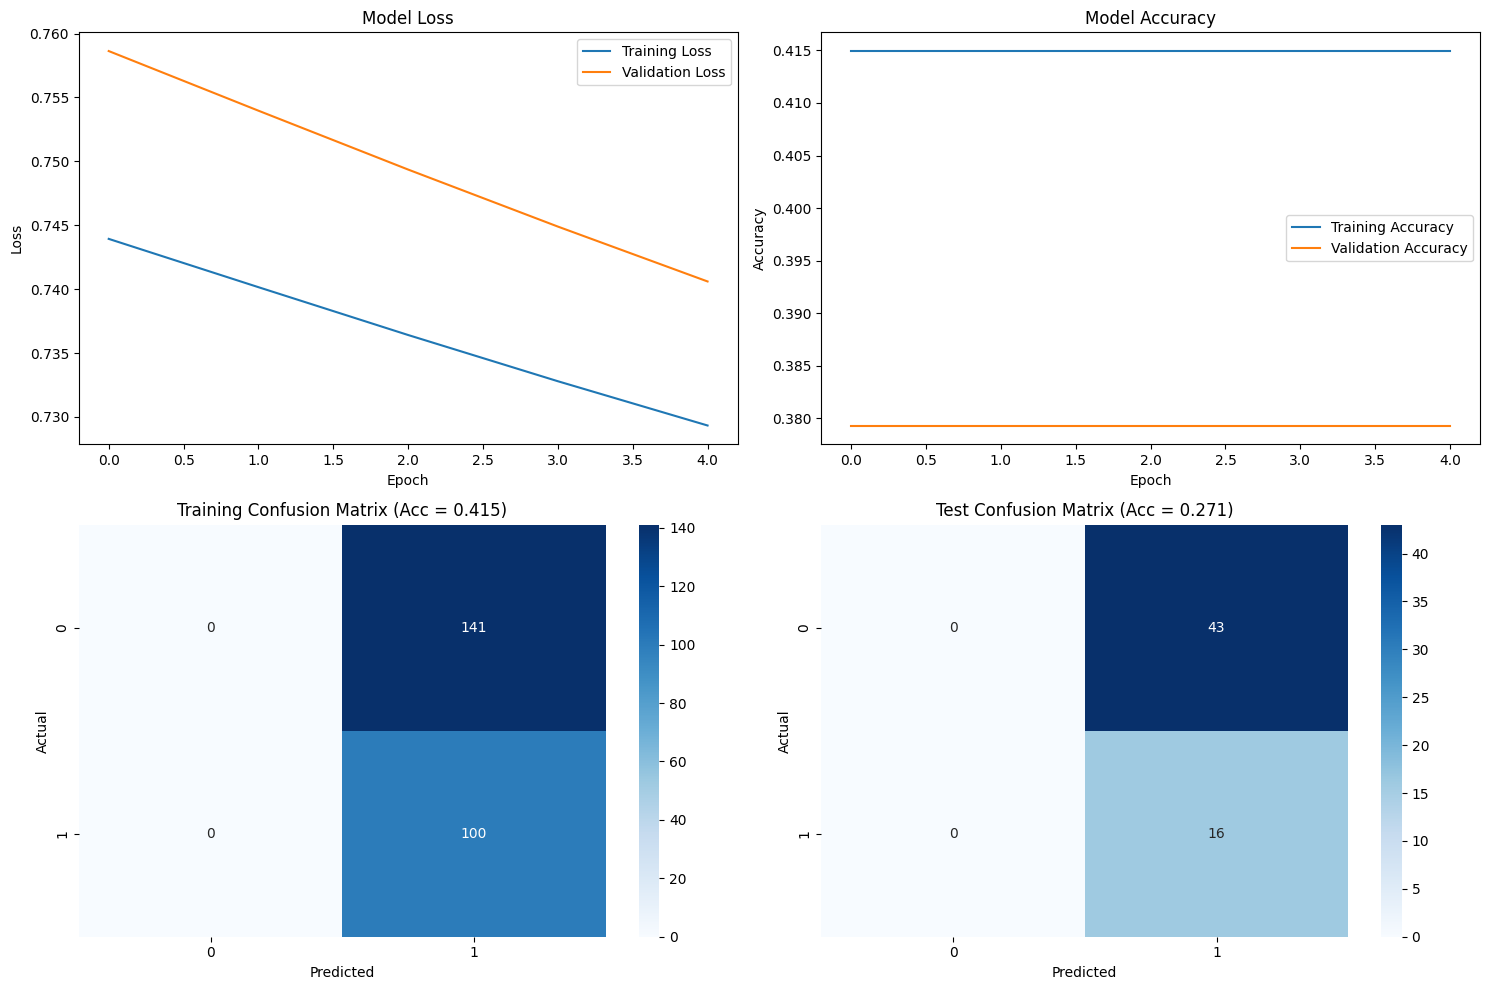

In [41]:
history16 = model16.fit(train_data_gen,
                        epochs=epochs,
                        validation_data=val_data_gen,
                        callbacks=callbacks,
                        verbose=1)

train_pred_prob = model16.predict(X_train)
test_pred_prob = model16.predict(X_test)
train_pred = (train_pred_prob > 0.5).astype(int)
test_pred = (test_pred_prob > 0.5).astype(int)

# Calculate classification metrics
train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)
train_prec = precision_score(y_train, train_pred)
test_prec = precision_score(y_test, test_pred)
train_rec = recall_score(y_train, train_pred)
test_rec = recall_score(y_test, test_pred)
train_f1 = f1_score(y_train, train_pred)
test_f1 = f1_score(y_test, test_pred)
train_auc = roc_auc_score(y_train, train_pred_prob)
test_auc = roc_auc_score(y_test, test_pred_prob)

# Print metrics
print(f"Training Metrics:")
print(f"Accuracy: {train_acc:.4f}, Precision: {train_prec:.4f}, Recall: {train_rec:.4f}")
print(f"F1-Score: {train_f1:.4f}, AUC: {train_auc:.4f}")
print(f"\nTest Metrics:")
print(f"Accuracy: {test_acc:.4f}, Precision: {test_prec:.4f}, Recall: {test_rec:.4f}")
print(f"F1-Score: {test_f1:.4f}, AUC: {test_auc:.4f}")

# Plot learning curves and predictions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Learning curves
axes[0,0].plot(history16.history['loss'], label='Training Loss')
axes[0,0].plot(history16.history['val_loss'], label='Validation Loss')
axes[0,0].set_title('Model Loss')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Loss')
axes[0,0].legend()

axes[0,1].plot(history16.history['accuracy'], label='Training Accuracy')
axes[0,1].plot(history16.history['val_accuracy'], label='Validation Accuracy')
axes[0,1].set_title('Model Accuracy')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Accuracy')
axes[0,1].legend()

# Confusion matrix visualization
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm_train = confusion_matrix(y_train, train_pred)
cm_test = confusion_matrix(y_test, test_pred)

sns.heatmap(cm_train, annot=True, fmt='d', ax=axes[1,0], cmap='Blues')
axes[1,0].set_title(f'Training Confusion Matrix (Acc = {train_acc:.3f})')
axes[1,0].set_xlabel('Predicted')
axes[1,0].set_ylabel('Actual')

sns.heatmap(cm_test, annot=True, fmt='d', ax=axes[1,1], cmap='Blues')
axes[1,1].set_title(f'Test Confusion Matrix (Acc = {test_acc:.3f})')
axes[1,1].set_xlabel('Predicted')
axes[1,1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [ ]:
# Predict on the test set using the trained model (model16)
y_pred16_scaled = model16.predict(X_test)

# Inverse transform the scaled predictions to get the predictions in the original scale
y_pred16 = target_scaler.inverse_transform(y_pred16_scaled)
y_test16 = target_scaler.inverse_transform(y_test.reshape(-1, 1))
# Calculate the Mean Squared Error (MSE), Mean Absolute Error (MAE) and R-squared (R²) score
mse16 = MeanSquaredError()(y_test16, y_pred16).numpy()
mae16 = tf.keras.losses.MeanAbsoluteError()(y_test16, y_pred16).numpy()
r2_16 = r2_score(y_test16, y_pred16)

print("LSTM 16 - MSE: ", mse16, "MAE: ", mae16, "R²: ", r2_16)
     

In [ ]:
plt.figure(figsize=(12, 8))
# Plot for model 16
epochs16 = range(1, len(history16.history['loss']) + 1)
plt.plot(epochs16, history16.history['loss'], label='Train Loss (LSTM 16)')
plt.plot(epochs16, history16.history['val_loss'], '--', label='Val Loss (LSTM 16)')


plt.title('Training and Validation Loss for Different LSTM Units')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:

plt.subplot(2, 2, 4)
plt.plot(y_test16, label='True')
plt.plot(y_pred16, label='Predicted')
plt.title('LSTM 128')
plt.xlabel('Sample index (Test Set)')
plt.ylabel('Precipitation')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

[I 2025-09-03 13:29:34,275] A new study created in memory with name: no-name-d83175b5-5781-4b9a-a1d0-51aea3cbb7f2
[I 2025-09-03 13:29:41,965] Trial 0 finished with value: 0.6585768461227417 and parameters: {'n_layers': 1, 'lstm_units_l0': 36, 'dropout_l0': 0.10122091355650967, 'learning_rate': 0.0003527707905188734, 'batch_size': 64, 'use_batch_norm': False, 'l2_reg': 1.2493915244955918e-05, 'use_extra_dense': True, 'dense_units': 23}. Best is trial 0 with value: 0.6585768461227417.
[I 2025-09-03 13:29:50,343] Trial 1 finished with value: 0.669248104095459 and parameters: {'n_layers': 2, 'lstm_units_l0': 59, 'lstm_units_l1': 44, 'dropout_l0': 0.1250519265015817, 'dropout_l1': 0.14940727771245765, 'learning_rate': 0.00014340242854027162, 'batch_size': 32, 'use_batch_norm': True, 'l2_reg': 1.0822828761926408e-06, 'use_extra_dense': False}. Best is trial 0 with value: 0.6585768461227417.
[I 2025-09-03 13:29:54,200] Trial 2 finished with value: 0.6859381198883057 and parameters: {'n_layers

Number of finished trials: 10
Best trial:
  Value: 0.6585768461227417
  Params:
    n_layers: 1
    lstm_units_l0: 36
    dropout_l0: 0.10122091355650967
    learning_rate: 0.0003527707905188734
    batch_size: 64
    use_batch_norm: False
    l2_reg: 1.2493915244955918e-05
    use_extra_dense: True
    dense_units: 23
Epoch 1/200
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5343 - auc: 0.5782 - loss: 0.6916 - precision: 0.5139 - recall: 0.9366

8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - accuracy: 0.4647 - auc: 0.5818 - loss: 0.7001 - precision: 0.4300 - recall: 0.8900 - val_accuracy: 0.3793 - val_auc: 0.6484 - val_loss: 0.7008 - val_precision: 0.3793 - val_recall: 1.0000 - learning_rate: 3.5277e-04
Epoch 2/200
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5312 - auc: 0.3945 - loss: 0.7035 - precision: 0.5172 - recall: 0.9375

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5311 - auc: 0.6017 - loss: 0.6901 - precision: 0.4564 - recall: 0.6800 - val_accuracy: 0.6724 - val_auc: 0.6540 - val_loss: 0.6870 - val_precision: 0.6154 - val_recall: 0.3636 - learning_rate: 3.5277e-04
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5442 - auc: 0.4907 - loss: 0.6944 - precision: 0.5264 - recall: 0.4953

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5892 - auc: 0.5353 - loss: 0.6888 - precision: 0.5063 - recall: 0.4000 - val_accuracy: 0.6207 - val_auc: 0.6730 - val_loss: 0.6784 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 3.5277e-04
Epoch 4/200
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5938 - auc: 0.5566 - loss: 0.6894 - precision: 0.8000 - recall: 0.2500

...

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5892 - auc: 0.5743 - loss: 0.6748 - precision: 0.6667 - recall: 0.0200 - val_accuracy: 0.6207 - val_auc: 0.6402 - val_loss: 0.6510 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 3.5277e-04
Epoch 26/200
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4688 - auc: 0.4277 - loss: 0.7103 - precision: 0.0000e+00 - recall: 0.0000e+00

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5768 - auc: 0.6076 - loss: 0.6668 - precision: 0.2500 - recall: 0.0100 - val_accuracy: 0.6207 - val_auc: 0.6433 - val_loss: 0.6504 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 3.5277e-04
Epoch 27/200
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4688 - auc: 0.3516 - loss: 0.7272 - precision: 0.0000e+00 - recall: 0.0000e+00

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5851 - auc: 0.6050 - loss: 0.6690 - precision: 0.5000 - recall: 0.0100 - val_accuracy: 0.6207 - val_auc: 0.6345 - val_loss: 0.6491 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 3.5277e-04
Epoch 28/200
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5312 - auc: 0.3711 - loss: 0.7149 - precision: 1.0000 - recall: 0.0625

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5851 - auc: 0.6095 - loss: 0.6670 - precision: 0.5000 - recall: 0.0100 - val_accuracy: 0.6379 - val_auc: 0.6370 - val_loss: 0.6478 - val_precision: 0.6667 - val_recall: 0.0909 - learning_rate: 3.5277e-04
Epoch 29/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5934 - auc: 0.6147 - loss: 0.6656 - precision: 0.6000 - recall: 0.0600 - val_accuracy: 0.6552 - val_auc: 0.6414 - val_loss: 0.6484 - val_precision: 0.6667 - val_recall: 0.1818 - learning_rate: 3.5277e-04
Epoch 30/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5975 - auc: 0.6150 - loss: 0.6636 - precision: 0.6000 - recall: 0.0900 - val_accuracy: 0.6379 - val_auc: 0.6338 - val_loss: 0.6500 - val_precision: 0.5714 - val_recall: 0.1818 - learning_rate: 3.5277e-04
Epoch 31/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5809 - auc: 0.5787 - loss: 0.6706 - precision: 0.4762 - recall: 0.1000 - val_accuracy: 0.6034 - val_auc: 0.6357 - val_loss: 0.6531 - val_precisi

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5851 - auc: 0.6133 - loss: 0.6649 - precision: 0.5000 - recall: 0.1000 - val_accuracy: 0.6379 - val_auc: 0.6383 - val_loss: 0.6471 - val_precision: 0.5455 - val_recall: 0.2727 - learning_rate: 3.5277e-04
Epoch 34/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5892 - auc: 0.6150 - loss: 0.6652 - precision: 0.5238 - recall: 0.1100 - val_accuracy: 0.6552 - val_auc: 0.6383 - val_loss: 0.6481 - val_precision: 0.5625 - val_recall: 0.4091 - learning_rate: 3.5277e-04
Epoch 35/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5892 - auc: 0.5998 - loss: 0.6688 - precision: 0.5172 - recall: 0.1500 - val_accuracy: 0.5862 - val_auc: 0.6364 - val_loss: 0.6570 - val_precision: 0.4667 - val_recall: 0.6364 - learning_rate: 3.5277e-04
Epoch 36/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6017 - auc: 0.6117 - loss: 0.6662 - precision: 0.5435 - recall: 0.2500 - val_accuracy: 0.6034 - val_auc: 0.6389 - val_loss: 0.6550 - val_precis

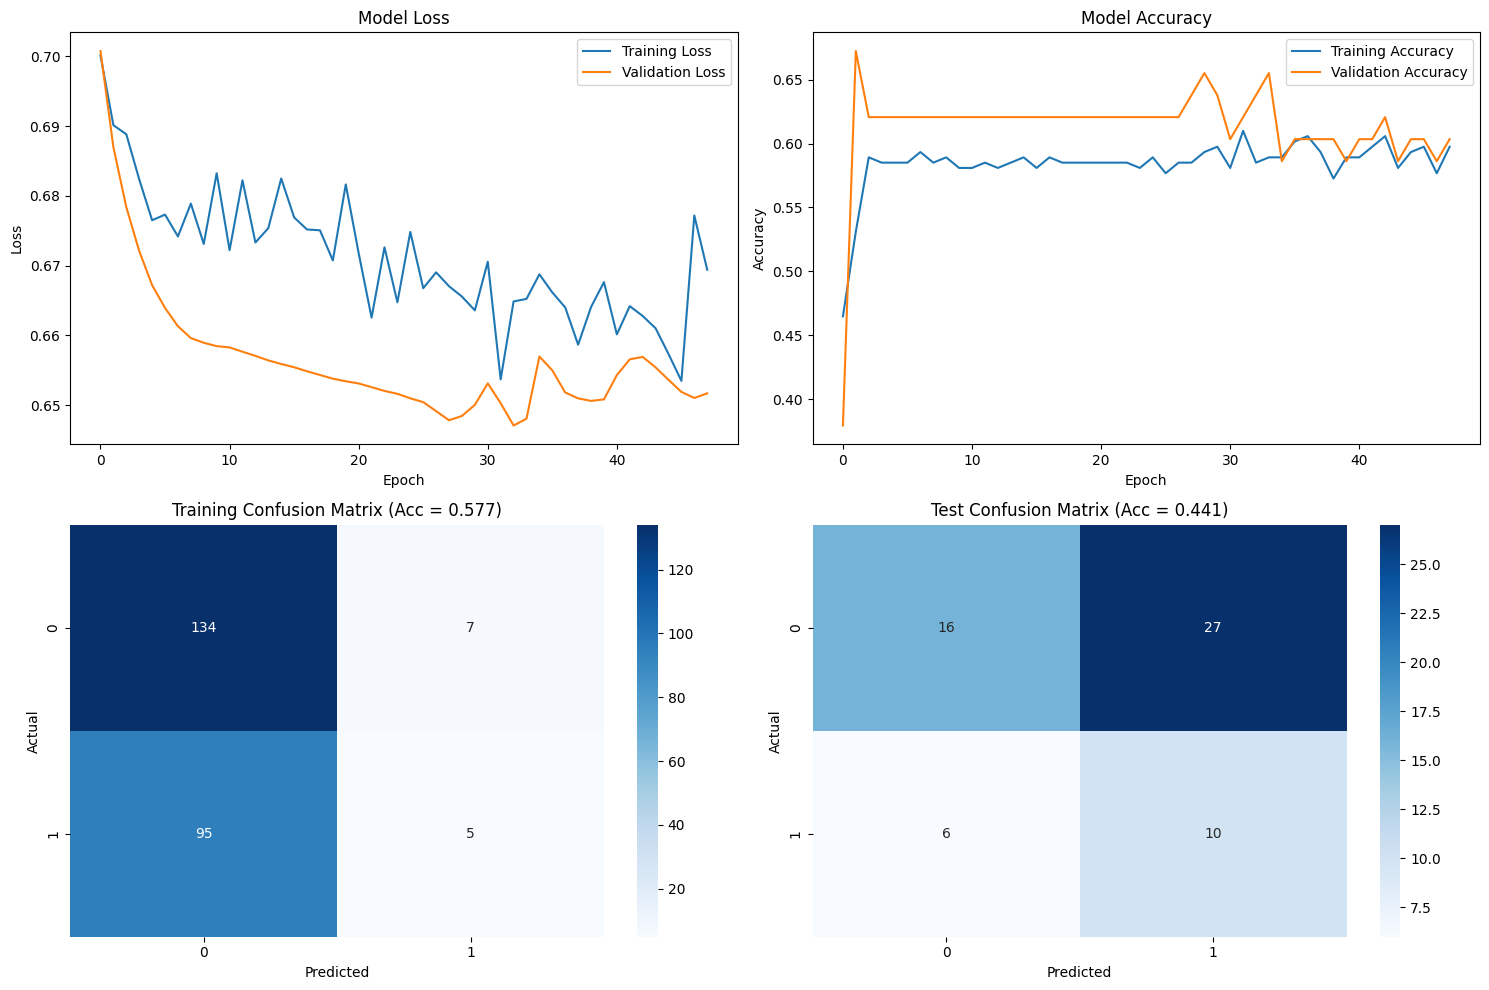

In [47]:
import optuna
import optuna
import numpy as np
from optuna.integration import TFKerasPruningCallback
import tensorflow as tf



def create_model(trial):
    """Create a model with hyperparameters suggested by Optuna, optimized for binary classification."""
    # Define hyperparameter search space with more conservative values
    n_layers = trial.suggest_int('n_layers', 1, 2)  # Reduzido para no máximo 2 camadas
    lstm_units = [trial.suggest_int(f'lstm_units_l{i}', 32, 64) for i in range(n_layers)]  # Unidades reduzidas
    dropout_rates = [trial.suggest_float(f'dropout_l{i}', 0.1, 0.3) for i in range(n_layers)]  # Aumentei o dropout mínimo
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 5e-4, log=True)  # Taxa de aprendizado reduzida
    batch_size = trial.suggest_categorical('batch_size', [32, 64])  # Tamanhos de batch razoáveis
    
    # Parâmetros adicionais para classificação
    use_bn = trial.suggest_categorical('use_batch_norm', [True, False])  # Batch normalization pode ajudar
    l2_reg = trial.suggest_float('l2_reg', 1e-6, 1e-4, log=True)  # Regularização L2 para evitar overfitting
    
    # Build model
    model = tf.keras.models.Sequential()
    
    # First LSTM layer
    if n_layers == 1:
        model.add(tf.keras.layers.LSTM(lstm_units[0], 
                                      input_shape=(n_steps, num_features),
                                      activation='tanh',  # tanh é geralmente melhor para LSTMs
                                      recurrent_activation='sigmoid',
                                      return_sequences=False,
                                      kernel_regularizer=tf.keras.regularizers.l2(l2_reg),
                                      recurrent_regularizer=tf.keras.regularizers.l2(l2_reg),
                                      dtype='float32'))
        if use_bn:
            model.add(tf.keras.layers.BatchNormalization())
        model.add(tf.keras.layers.Dropout(dropout_rates[0]))
    else:
        model.add(tf.keras.layers.LSTM(lstm_units[0], 
                                      return_sequences=True, 
                                      input_shape=(n_steps, num_features),
                                      activation='tanh',  # tanh é geralmente melhor para LSTMs
                                      recurrent_activation='sigmoid',
                                      kernel_regularizer=tf.keras.regularizers.l2(l2_reg),
                                      recurrent_regularizer=tf.keras.regularizers.l2(l2_reg),
                                      dtype='float32'))
        if use_bn:
            model.add(tf.keras.layers.BatchNormalization())
        model.add(tf.keras.layers.Dropout(dropout_rates[0]))
        
        # Last LSTM layer
        model.add(tf.keras.layers.LSTM(lstm_units[-1],
                                     kernel_regularizer=tf.keras.regularizers.l2(l2_reg),
                                     recurrent_regularizer=tf.keras.regularizers.l2(l2_reg)))
        if use_bn:
            model.add(tf.keras.layers.BatchNormalization())
        model.add(tf.keras.layers.Dropout(dropout_rates[-1]))
    
    # Camada intermediária opcional para classificação
    use_extra_dense = trial.suggest_categorical('use_extra_dense', [True, False])
    if use_extra_dense:
        dense_units = trial.suggest_int('dense_units', 16, 32)
        model.add(tf.keras.layers.Dense(dense_units, activation='relu',
                                       kernel_regularizer=tf.keras.regularizers.l2(l2_reg)))
        if use_bn:
            model.add(tf.keras.layers.BatchNormalization())
        model.add(tf.keras.layers.Dropout(0.2))
    
    # Output layer - otimizado para classificação binária
    # Combinamos a Dense(1) e Activation('sigmoid') em uma única camada
    model.add(tf.keras.layers.Dense(1, activation='sigmoid',
                                  kernel_regularizer=tf.keras.regularizers.l2(l2_reg)))
    
    # Compile model com métricas específicas para classificação
    optimizer = tf.keras.optimizers.Adam(
        learning_rate=learning_rate, 
        clipnorm=0.1,  # Clipnorm para evitar explosão de gradientes
        epsilon=1e-7   # Epsilon para estabilidade numérica
    )
    
    # Métricas focadas em classificação binária
    metrics = [
        tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc'),
    ]
    
    model.compile(
        optimizer=optimizer, 
        loss='binary_crossentropy',  # Loss adequada para classificação binária
        metrics=metrics
    )

    # Early stopping e class weights podem ser definidos fora desta função
    
    return model, batch_size

def objective(trial):
    """Objective function for Optuna optimization."""
    # Create model with suggested hyperparameters
    model, batch_size = create_model(trial)
    
    # Define callbacks
    callbacks = [
        TFKerasPruningCallback(trial, 'val_loss'),
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
    ]
    
    # Train model
    history = model.fit(
        train_data_gen,
        epochs=50,  # Maximum epochs for each trial
        batch_size=batch_size,
        validation_data=val_data_gen,
        callbacks=callbacks,
        verbose=0
    )
    
    # Return validation loss
    return history.history['val_loss'][-1]

# Create Optuna study
study = optuna.create_study(direction='minimize', pruner=optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=10)  # Adjust number of trials based on your resources

# Print optimization results
print('Number of finished trials:', len(study.trials))
print('Best trial:')
trial = study.best_trial
print('  Value:', trial.value)
print('  Params:')
for key, value in trial.params.items():
    print(f'    {key}: {value}')

# Train final model with best hyperparameters
best_model, best_batch_size = create_model(trial)
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
    ModelCheckpoint('best_model.h5', save_best_only=True)
]

history = best_model.fit(
    train_data_gen,
    epochs=50,
    batch_size=best_batch_size,
    validation_data=val_data_gen,
    callbacks=callbacks,
    verbose=1,
    
)

#Make Predictions

train_pred_prob = best_model.predict(X_train)
test_pred_prob = best_model.predict(X_test)
train_pred = (train_pred_prob > 0.5).astype(int)
test_pred = (test_pred_prob > 0.5).astype(int)

# Calculate classification metrics
train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)
train_prec = precision_score(y_train, train_pred)
test_prec = precision_score(y_test, test_pred)
train_rec = recall_score(y_train, train_pred)
test_rec = recall_score(y_test, test_pred)
train_f1 = f1_score(y_train, train_pred)
test_f1 = f1_score(y_test, test_pred)
train_auc = roc_auc_score(y_train, train_pred_prob)
test_auc = roc_auc_score(y_test, test_pred_prob)

# Print metrics
print(f"Training Metrics:")
print(f"Accuracy: {train_acc:.4f}, Precision: {train_prec:.4f}, Recall: {train_rec:.4f}")
print(f"F1-Score: {train_f1:.4f}, AUC: {train_auc:.4f}")
print(f"\nTest Metrics:")
print(f"Accuracy: {test_acc:.4f}, Precision: {test_prec:.4f}, Recall: {test_rec:.4f}")
print(f"F1-Score: {test_f1:.4f}, AUC: {test_auc:.4f}")

# Plot learning curves and predictions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Learning curves
axes[0,0].plot(history.history['loss'], label='Training Loss')
axes[0,0].plot(history.history['val_loss'], label='Validation Loss')
axes[0,0].set_title('Model Loss')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Loss')
axes[0,0].legend()

axes[0,1].plot(history.history['accuracy'], label='Training Accuracy')
axes[0,1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0,1].set_title('Model Accuracy')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Accuracy')
axes[0,1].legend()

# Confusion matrix visualization
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm_train = confusion_matrix(y_train, train_pred)
cm_test = confusion_matrix(y_test, test_pred)

sns.heatmap(cm_train, annot=True, fmt='d', ax=axes[1,0], cmap='Blues')
axes[1,0].set_title(f'Training Confusion Matrix (Acc = {train_acc:.3f})')
axes[1,0].set_xlabel('Predicted')
axes[1,0].set_ylabel('Actual')

sns.heatmap(cm_test, annot=True, fmt='d', ax=axes[1,1], cmap='Blues')
axes[1,1].set_title(f'Test Confusion Matrix (Acc = {test_acc:.3f})')
axes[1,1].set_xlabel('Predicted')
axes[1,1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [ ]:
# Predict on the test set using the trained model (model_optuna)
y_pred_optuna_scaled = best_model.predict(X_test)

# Inverse transform the scaled predictions to get the predictions in the original scale
y_pred_optuna = target_scaler.inverse_transform(y_pred_optuna_scaled)
y_test_optuna = target_scaler.inverse_transform(y_test.reshape(-1, 1))
# Calculate the Mean Squared Error (MSE), Mean Absolute Error (MAE) and R-squared (R²) score
mse_optuna = MeanSquaredError()(y_test_optuna, y_pred_optuna).numpy()
mae_optuna = tf.keras.losses.MeanAbsoluteError()(y_test_optuna, y_pred_optuna).numpy()
r2__optuna = r2_score(y_test_optuna, y_pred_optuna)

print("LSTM _optuna - MSE: ", mse_optuna, "MAE: ", mae_optuna, "R²: ", r2__optuna)

In [ ]:
# Plot learning curves and predictions
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Learning curves
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Model Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['mae'], label='Training MAE')
axes[1].plot(history.history['val_mae'], label='Validation MAE')
axes[1].set_title('Model MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()


plt.tight_layout()
plt.show()

In [42]:
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, LayerNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
# n_steps = X_tr.shape[1]      # 24 * n_days_history
# n_feats = X_tr.shape[2]      # len(feature_cols)


model = Sequential([
    LSTM(16, return_sequences=True, input_shape=(n_steps, num_features)),
    Dense(8),
    Dense(1, activation='sigmoid')
])
opt = tf.keras.optimizers.Adam(learning_rate=1e-3, clipnorm=0.5)

model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['recall', 'precision', 'accuracy', 'AUC'])
#reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, mode='min', patience=10, min_lr=1e-7, verbose=1)


early_stop = EarlyStopping(monitor='val_loss', mode='min', patience=20, restore_best_weights=True)
ckpt = ModelCheckpoint('best_lstm.keras', monitor='val_loss', save_best_only=True)

history = model.fit(
    train_data_gen,
    validation_data=val_data_gen,
    epochs=100,
    batch_size=64,
    shuffle=False,
    callbacks=[early_stop, ckpt],
    verbose=1
)

# Make predictions
train_pred_prob = model.predict(X_train)
test_pred_prob = model.predict(X_test)
train_pred = (train_pred_prob > 0.5).astype(int)
test_pred = (test_pred_prob > 0.5).astype(int)

# Calculate classification metrics
train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)
train_prec = precision_score(y_train, train_pred)
test_prec = precision_score(y_test, test_pred)
train_rec = recall_score(y_train, train_pred)
test_rec = recall_score(y_test, test_pred)
train_f1 = f1_score(y_train, train_pred)
test_f1 = f1_score(y_test, test_pred)
train_auc = roc_auc_score(y_train, train_pred_prob)
test_auc = roc_auc_score(y_test, test_pred_prob)

# Print metrics
print(f"Training Metrics:")
print(f"Accuracy: {train_acc:.4f}, Precision: {train_prec:.4f}, Recall: {train_rec:.4f}")
print(f"F1-Score: {train_f1:.4f}, AUC: {train_auc:.4f}")
print(f"\nTest Metrics:")
print(f"Accuracy: {test_acc:.4f}, Precision: {test_prec:.4f}, Recall: {test_rec:.4f}")
print(f"F1-Score: {test_f1:.4f}, AUC: {test_auc:.4f}")

# Plot learning curves and predictions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Learning curves
axes[0,0].plot(history.history['loss'], label='Training Loss')
axes[0,0].plot(history.history['val_loss'], label='Validation Loss')
axes[0,0].set_title('Model Loss')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Loss')
axes[0,0].legend()

axes[0,1].plot(history.history['accuracy'], label='Training Accuracy')
axes[0,1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0,1].set_title('Model Accuracy')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Accuracy')
axes[0,1].legend()

# Confusion matrix visualization
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm_train = confusion_matrix(y_train, train_pred)
cm_test = confusion_matrix(y_test, test_pred)

sns.heatmap(cm_train, annot=True, fmt='d', ax=axes[1,0], cmap='Blues')
axes[1,0].set_title(f'Training Confusion Matrix (Acc = {train_acc:.3f})')
axes[1,0].set_xlabel('Predicted')
axes[1,0].set_ylabel('Actual')

sns.heatmap(cm_test, annot=True, fmt='d', ax=axes[1,1], cmap='Blues')
axes[1,1].set_title(f'Test Confusion Matrix (Acc = {test_acc:.3f})')
axes[1,1].set_xlabel('Predicted')
axes[1,1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

Epoch 1/100


ValueError: Arguments `target` and `output` must have the same rank (ndim). Received: target.shape=(None,), output.shape=(None, 48, 1)

In [ ]:
# from sklearn.preprocessing import MinMaxScaler,StandardScaler
# from sklearn.utils.class_weight import compute_class_weight
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import LSTM, Dense, Dropout, LayerNormalization
# from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
# import tensorflow as tf

# def create_sequences(data, target_col, n_steps=60):
#     """Create sequences for LSTM training, removendo a coluna do target das features"""
#     X, y = [], []
#     for i in range(n_steps, len(data)):
#         # Seleciona janela e remove a coluna do target
#         window = np.delete(data[i-n_steps:i], target_col, axis=1)
#         X.append(window)
#         # Alvo no tempo i
#         y.append(data[i, target_col])
#     return np.array(X), np.array(y)
# def build_lstm_pipeline(df, target_column='rain_day', n_steps=60, test_size=0.2, feature_cols=None):
#     """Complete LSTM pipeline with training, evaluation and visualization"""
    
#     # Prepare data
    
#     data = df[feature_cols].values
#     target_idx = feature_cols.index(target_column) if target_column in feature_cols else -1

#     # 1) Split temporal
#     df_train = df[feature_cols].copy()
#     df_target = df[target_column].copy()

#     split_idx = int(len(df) * (1 - test_size))
#     X_train_df, X_test_df = df_train.iloc[:split_idx], df_train.iloc[split_idx:]
#     y_train_s, y_test_s = df_target.iloc[:split_idx], df_target.iloc[split_idx:]

#     class_weights = compute_class_weight(
#     class_weight='balanced',
#     classes=np.unique(y_train_s),
#     y=y_train_s
#     )
#     class_weight_dict = dict(enumerate(class_weights))
#     print(class_weight_dict)
    
#     # 2) Escalonar **só com treino**
#     scaler = StandardScaler().fit(X_train_df.values)
#     X_train = scaler.transform(X_train_df.values)
#     X_test  = scaler.transform(X_test_df.values)

#     # 3) Voltar para DataFrame (preserva índice e nomes)
#     X_train_df_scaled = pd.DataFrame(X_train, index=X_train_df.index, columns=feature_cols)
#     X_test_df_scaled  = pd.DataFrame(X_test,  index=X_test_df.index,  columns=feature_cols)

#     # 4) Concatenar X e y como colunas (lado a lado)
#     train_data = pd.concat([X_train_df_scaled, y_train_s.rename(target_column)], axis=1)
#     test_data  = pd.concat([X_test_df_scaled,  y_test_s.rename(target_column)],  axis=1)

#     # 5) Pegar a posição da coluna-alvo
#     target_idx = train_data.columns.get_loc(target_column)

#     # 6) Criar sequências
#     X_tr, y_tr = create_sequences(train_data.values, target_idx, n_steps)
#     X_te, y_te = create_sequences(test_data.values,  target_idx, n_steps)
#     # Train-test split

#     # Build LSTM model for classification
#     model = Sequential([
#         LSTM(1, return_sequences=True, input_shape=(n_steps, len(feature_cols))),
#         Dropout(0.3),
#         LSTM(2, return_sequences=True),
#         Dropout(0.3),
#         LSTM(4, return_sequences=False),        
#         LayerNormalization(),
#         Dense(1, activation='sigmoid')
#     ])
#     opt = tf.keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0)

#     model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['recall', 'precision', 'accuracy', 'AUC', ])

#     # Train model
#     early_stop = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)

#     reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=10, min_lr=1e-6, verbose=1)
#     ckpt = ModelCheckpoint('best_lstm.keras', monitor='val_loss', save_best_only=True)
#     history = model.fit(X_tr, y_tr, 
#                        batch_size=32, epochs=1000, 
#                        validation_data=(X_te, y_te), 
#                        callbacks=[early_stop, reduce_lr, ckpt], 
#                        shuffle=False,
#                        verbose=1,
#                        class_weight=class_weight_dict)
    
#     # Make predictions
#     train_pred_prob = model.predict(X_tr)
#     test_pred_prob = model.predict(X_te)
#     train_pred = (train_pred_prob > 0.5).astype(int)
#     test_pred = (test_pred_prob > 0.5).astype(int)
    
#     # Calculate classification metrics
#     train_acc = accuracy_score(y_tr, train_pred)
#     test_acc = accuracy_score(y_te, test_pred)
#     train_prec = precision_score(y_tr, train_pred)
#     test_prec = precision_score(y_te, test_pred)
#     train_rec = recall_score(y_tr, train_pred)
#     test_rec = recall_score(y_te, test_pred)
#     train_f1 = f1_score(y_tr, train_pred)
#     test_f1 = f1_score(y_te, test_pred)
#     train_auc = roc_auc_score(y_tr, train_pred_prob)
#     test_auc = roc_auc_score(y_te, test_pred_prob)

#     # Print metrics
#     print(f"Training Metrics:")
#     print(f"Accuracy: {train_acc:.4f}, Precision: {train_prec:.4f}, Recall: {train_rec:.4f}")
#     print(f"F1-Score: {train_f1:.4f}, AUC: {train_auc:.4f}")
#     print(f"\nTest Metrics:")
#     print(f"Accuracy: {test_acc:.4f}, Precision: {test_prec:.4f}, Recall: {test_rec:.4f}")
#     print(f"F1-Score: {test_f1:.4f}, AUC: {test_auc:.4f}")
    
#     # Plot learning curves and predictions
#     fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
#     # Learning curves
#     axes[0,0].plot(history.history['loss'], label='Training Loss')
#     axes[0,0].plot(history.history['val_loss'], label='Validation Loss')
#     axes[0,0].set_title('Model Loss')
#     axes[0,0].set_xlabel('Epoch')
#     axes[0,0].set_ylabel('Loss')
#     axes[0,0].legend()
    
#     axes[0,1].plot(history.history['accuracy'], label='Training Accuracy')
#     axes[0,1].plot(history.history['val_accuracy'], label='Validation Accuracy')
#     axes[0,1].set_title('Model Accuracy')
#     axes[0,1].set_xlabel('Epoch')
#     axes[0,1].set_ylabel('Accuracy')
#     axes[0,1].legend()
    
#     # Confusion matrix visualization
#     from sklearn.metrics import confusion_matrix
#     import seaborn as sns
    
#     cm_train = confusion_matrix(y_tr, train_pred)
#     cm_test = confusion_matrix(y_te, test_pred)
    
#     sns.heatmap(cm_train, annot=True, fmt='d', ax=axes[1,0], cmap='Blues')
#     axes[1,0].set_title(f'Training Confusion Matrix (Acc = {train_acc:.3f})')
#     axes[1,0].set_xlabel('Predicted')
#     axes[1,0].set_ylabel('Actual')
    
#     sns.heatmap(cm_test, annot=True, fmt='d', ax=axes[1,1], cmap='Blues')
#     axes[1,1].set_title(f'Test Confusion Matrix (Acc = {test_acc:.3f})')
#     axes[1,1].set_xlabel('Predicted')
#     axes[1,1].set_ylabel('Actual')
    
#     plt.tight_layout()
#     plt.show()
    
#     return model, history, scaler

# # Run the pipeline
# #feature_cols = ['T', 'rh', 'SWDR', 'p', 'wd_rad',"month_sin", "month_cos", "VPdef"]
# #feature_cols = ['rh', 'Tdew', 'VPdef', 'VPact', 'p', 'wv', 'wd', 'SWDR', 'PAR', 'T'] 
# feature_cols = ['T', 'rh', 'SWDR', 'p', 'wd_rad', "dayofweek_sin","dayofweek_cos",]
# model, history, scaler = build_lstm_pipeline(df, target_column='rain_day', n_steps=72, feature_cols=feature_cols)